<a href="https://colab.research.google.com/github/souhaylelhammadi/Introduction-l-informatique-quantique/blob/main/Copie_de_TP2_SGD_Stochastic_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 : Stochastic Gradient Descent (SGD)

## Objectifs
- Comprendre le principe du **Stochastic Gradient Descent**
- Implémenter l'algorithme **from scratch**
- Comparer avec le Batch Gradient Descent (TP1)
- Optimiser une fonction **simple** et une fonction **complexe**
- Visualiser le **chemin de convergence bruitée**
- Appliquer le SGD à la **classification** et évaluer les performances

---

## 1. Théorie

### Principe
Le **Stochastic Gradient Descent** (SGD) met à jour les paramètres en utilisant le gradient calculé sur **un seul échantillon** choisi aléatoirement à chaque itération :

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla J_i(\theta_t)$$

où $J_i$ est la fonction de coût calculée sur **un seul exemple** $(x_i, y_i)$.

### Différence avec le Batch GD
| | Batch GD | SGD |
|---|---|---|
| Données par itération | **Tout** le dataset | **1 seul** échantillon |
| Mise à jour | Lisse, déterministe | Bruitée, stochastique |
| Vitesse par itération | Lente ($O(N)$) | Rapide ($O(1)$) |
| Convergence | Directe vers le minimum | Oscillations autour du minimum |
| Minima locaux | Peut rester bloqué | Peut s'échapper grâce au bruit |

### Avantages
- **Très rapide** par itération (un seul exemple)
- Le bruit peut aider à **sortir des minima locaux**
- Peut commencer à apprendre **avant d'avoir vu tout le dataset**

### Inconvénients
- Convergence **bruitée** (oscillations)
- Peut ne jamais converger exactement au minimum
- Nécessite souvent un **learning rate décroissant** (learning rate schedule)

## 2. Imports et Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

## 3. Implémentation du SGD pour l'optimisation de fonctions

Pour l'optimisation de fonctions mathématiques (pas de données), on simule le comportement stochastique en ajoutant du **bruit gaussien** au gradient exact. Cela imite le fait que le SGD n'utilise qu'un estimateur bruité du vrai gradient.

In [2]:
def sgd_optimize(gradient_func, x_init, learning_rate=0.01, n_iterations=1000,
                 noise_scale=0.5, tol=1e-8, lr_decay=False):
    """
    Stochastic Gradient Descent pour l'optimisation de fonctions.
    On simule la stochasticité en ajoutant du bruit au gradient.

    Paramètres:
    -----------
    gradient_func : callable
        Gradient exact de la fonction
    x_init : np.array
        Point de départ
    learning_rate : float
        Taux d'apprentissage initial
    n_iterations : int
        Nombre d'itérations
    noise_scale : float
        Échelle du bruit ajouté au gradient (simule la stochasticité)
    lr_decay : bool
        Si True, le learning rate décroît au fil des itérations
    """
    x = np.array(x_init, dtype=float)
    path = [x.copy()]

    for i in range(n_iterations):
        # Learning rate décroissant (optionnel)
        if lr_decay:
            lr = learning_rate / (1 + 0.01 * i)
        else:
            lr = learning_rate

        # Gradient exact + bruit stochastique
        grad = gradient_func(x)
        noisy_grad = grad + noise_scale * np.random.randn(*grad.shape)

        # Mise à jour
        x = x - lr * noisy_grad
        path.append(x.copy())

    return path

On implémente aussi le Batch GD pour comparer :

In [3]:
def batch_gradient_descent(gradient_func, x_init, learning_rate=0.01, n_iterations=1000, tol=1e-8):
    """Batch Gradient Descent (rappel du TP1)"""
    x = np.array(x_init, dtype=float)
    path = [x.copy()]

    for i in range(n_iterations):
        grad = gradient_func(x)
        if np.linalg.norm(grad) < tol:
            break
        x = x - learning_rate * grad
        path.append(x.copy())

    return path

## 4. Fonction Simple : Fonction Quadratique

$$f(x, y) = x^2 + y^2$$

Minimum global en $(0, 0)$.

In [4]:
def f_simple(x):
    return x[0]**2 + x[1]**2

def grad_simple(x):
    return np.array([2*x[0], 2*x[1]])

In [5]:
x_init = np.array([4.0, 3.0])

# SGD (avec bruit)
path_sgd = sgd_optimize(grad_simple, x_init, learning_rate=0.05, n_iterations=200, noise_scale=1.0)

# Batch GD (sans bruit) pour comparaison
path_bgd = batch_gradient_descent(grad_simple, x_init, learning_rate=0.05, n_iterations=200)

print("=== SGD ===")
print(f"Point d'arrivée : {path_sgd[-1]}")
print(f"f finale : {f_simple(path_sgd[-1]):.6f}")
print(f"\n=== Batch GD ===")
print(f"Point d'arrivée : {path_bgd[-1]}")
print(f"f finale : {f_simple(path_bgd[-1]):.6f}")

=== SGD ===
Point d'arrivée : [ 0.04136285 -0.18498633]
f finale : 0.035931

=== Batch GD ===
Point d'arrivée : [3.87109965e-09 2.90332474e-09]
f finale : 0.000000


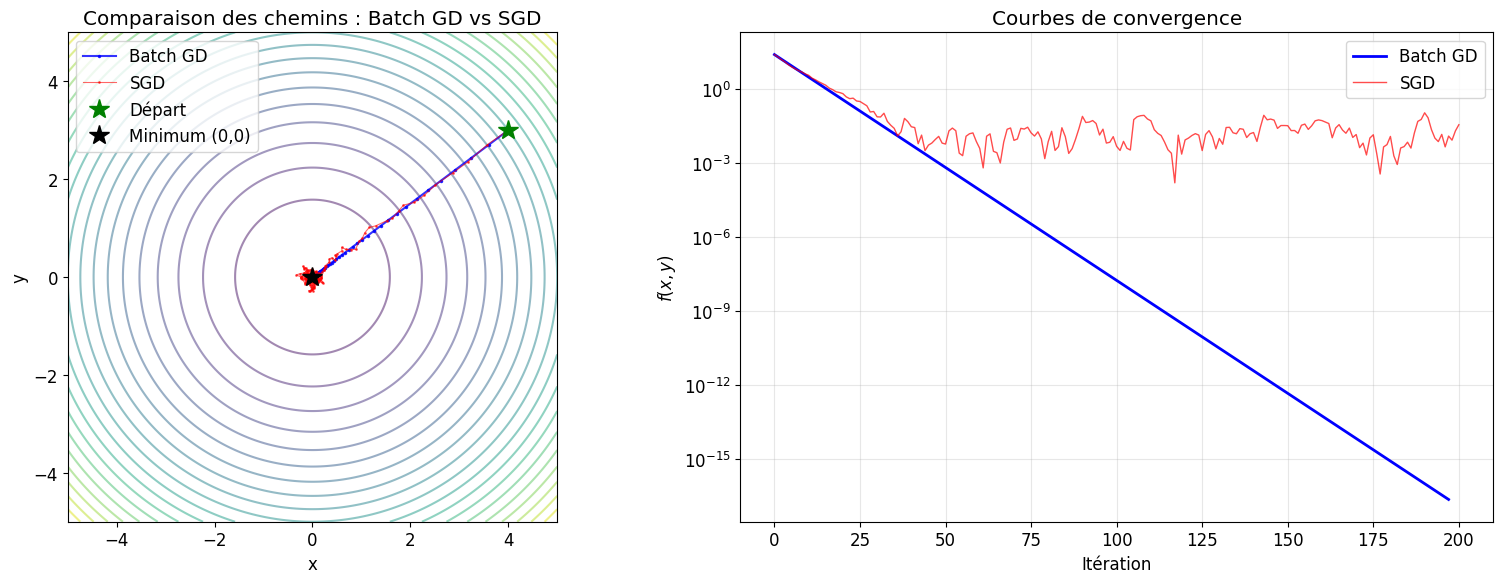


Observation : Le SGD oscille autour du minimum (chemin bruité),
tandis que le Batch GD converge de manière lisse et directe.


In [6]:
# Visualisation comparative
x_range = np.linspace(-5, 5, 200)
y_range = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

path_sgd_arr = np.array(path_sgd)
path_bgd_arr = np.array(path_bgd)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Figure 1 : Chemins de convergence ---
ax1 = axes[0]
ax1.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.5)
ax1.plot(path_bgd_arr[:, 0], path_bgd_arr[:, 1], 'b.-', markersize=3, linewidth=1.5, alpha=0.8, label='Batch GD')
ax1.plot(path_sgd_arr[:, 0], path_sgd_arr[:, 1], 'r.-', markersize=2, linewidth=0.8, alpha=0.6, label='SGD')
ax1.plot(x_init[0], x_init[1], 'g*', markersize=15, label='Départ')
ax1.plot(0, 0, 'k*', markersize=15, label='Minimum (0,0)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Comparaison des chemins : Batch GD vs SGD')
ax1.legend()
ax1.set_aspect('equal')

# --- Figure 2 : Courbes de convergence ---
ax2 = axes[1]
f_bgd = [f_simple(p) for p in path_bgd]
f_sgd = [f_simple(p) for p in path_sgd]
ax2.plot(f_bgd, 'b-', linewidth=2, label='Batch GD')
ax2.plot(f_sgd, 'r-', linewidth=1, alpha=0.7, label='SGD')
ax2.set_xlabel('Itération')
ax2.set_ylabel('$f(x, y)$')
ax2.set_title('Courbes de convergence')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservation : Le SGD oscille autour du minimum (chemin bruité),")
print("tandis que le Batch GD converge de manière lisse et directe.")

### Effet du Learning Rate Schedule

Le SGD bénéficie fortement d'un **learning rate décroissant** : grand au début pour avancer vite, puis petit pour se stabiliser.

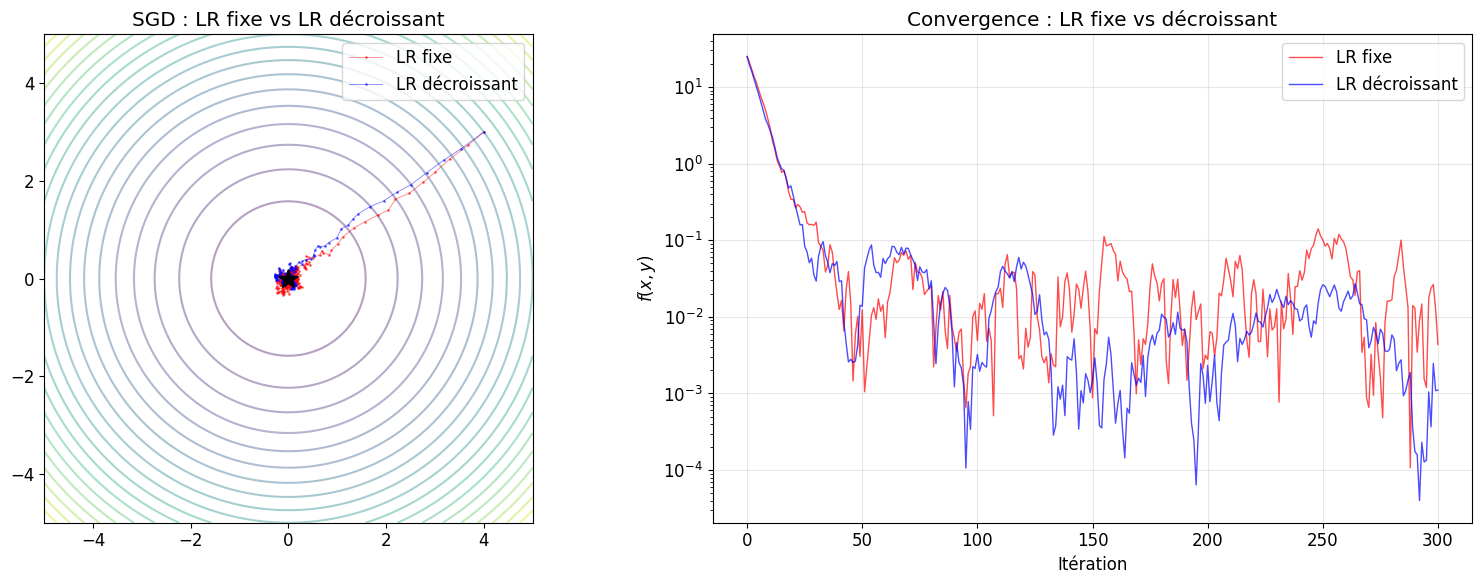

Le LR décroissant permet au SGD de se stabiliser davantage autour du minimum.


In [7]:
# SGD avec learning rate fixe vs décroissant
path_sgd_fixed = sgd_optimize(grad_simple, x_init, learning_rate=0.05, n_iterations=300,
                               noise_scale=1.0, lr_decay=False)
path_sgd_decay = sgd_optimize(grad_simple, x_init, learning_rate=0.05, n_iterations=300,
                               noise_scale=1.0, lr_decay=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chemins
ax1 = axes[0]
ax1.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.4)
path_fixed_arr = np.array(path_sgd_fixed)
path_decay_arr = np.array(path_sgd_decay)
ax1.plot(path_fixed_arr[:, 0], path_fixed_arr[:, 1], 'r.-', markersize=2, linewidth=0.6, alpha=0.5, label='LR fixe')
ax1.plot(path_decay_arr[:, 0], path_decay_arr[:, 1], 'b.-', markersize=2, linewidth=0.6, alpha=0.5, label='LR décroissant')
ax1.plot(0, 0, 'k*', markersize=15)
ax1.set_title('SGD : LR fixe vs LR décroissant')
ax1.legend()
ax1.set_aspect('equal')

# Convergence
ax2 = axes[1]
f_fixed = [f_simple(p) for p in path_sgd_fixed]
f_decay = [f_simple(p) for p in path_sgd_decay]
ax2.plot(f_fixed, 'r-', linewidth=1, alpha=0.7, label='LR fixe')
ax2.plot(f_decay, 'b-', linewidth=1, alpha=0.7, label='LR décroissant')
ax2.set_xlabel('Itération')
ax2.set_ylabel('$f(x,y)$')
ax2.set_title('Convergence : LR fixe vs décroissant')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Le LR décroissant permet au SGD de se stabiliser davantage autour du minimum.")

## 5. Fonction Complexe : Fonction de Rosenbrock

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

Minimum global en $(1, 1)$.

In [8]:
def f_rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    dfdx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
    dfdy = 200 * (x[1] - x[0]**2)
    return np.array([dfdx, dfdy])

In [9]:
x_init_rosen = np.array([-1.5, 1.5])

# SGD avec LR décroissant (nécessaire pour la Rosenbrock)
path_sgd_rosen = sgd_optimize(grad_rosenbrock, x_init_rosen, learning_rate=0.0005,
                               n_iterations=10000, noise_scale=0.5, lr_decay=True)

# Batch GD pour comparaison
path_bgd_rosen = batch_gradient_descent(grad_rosenbrock, x_init_rosen,
                                         learning_rate=0.001, n_iterations=10000)

print("=== SGD ===")
print(f"Point d'arrivée : {path_sgd_rosen[-1]}")
print(f"f finale : {f_rosenbrock(path_sgd_rosen[-1]):.6f}")
print(f"\n=== Batch GD ===")
print(f"Point d'arrivée : {path_bgd_rosen[-1]}")
print(f"f finale : {f_rosenbrock(path_bgd_rosen[-1]):.6f}")

=== SGD ===
Point d'arrivée : [-1.09979702  1.21742681]
f finale : 4.415346

=== Batch GD ===
Point d'arrivée : [0.99133699 0.98271418]
f finale : 0.000075


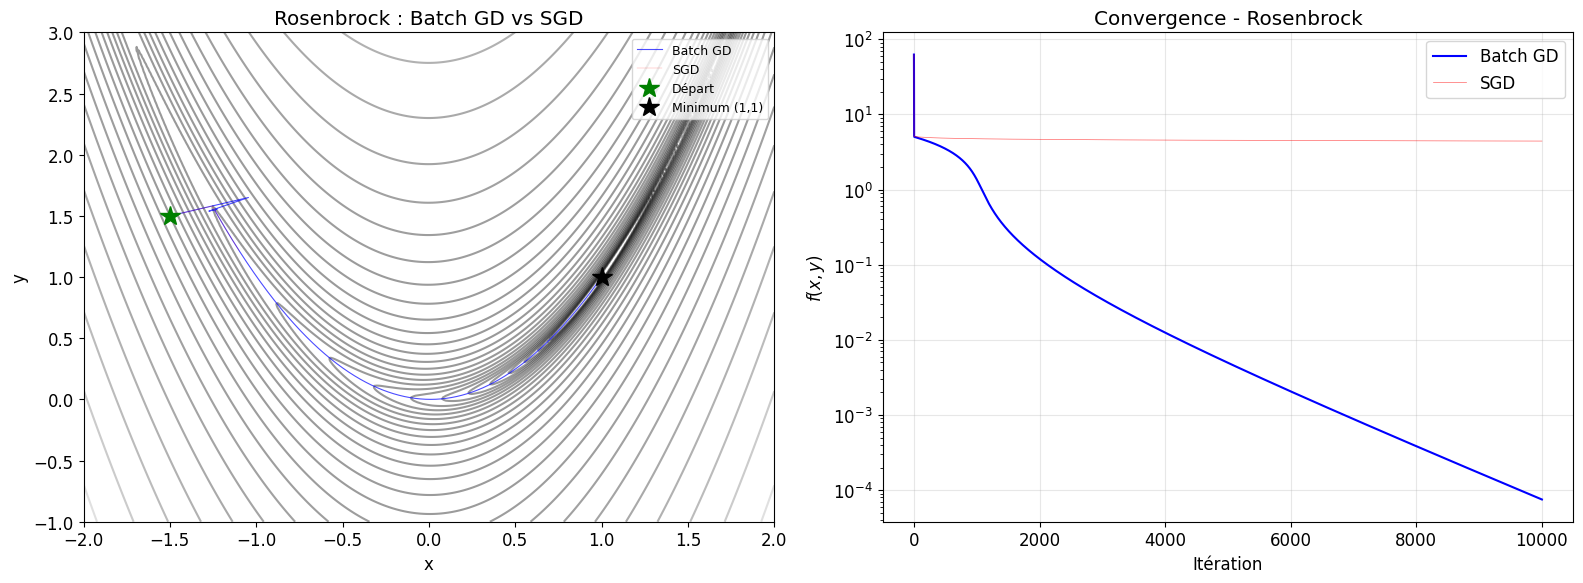

In [10]:
# Visualisation sur la Rosenbrock
x_range_r = np.linspace(-2, 2, 300)
y_range_r = np.linspace(-1, 3, 300)
Xr, Yr = np.meshgrid(x_range_r, y_range_r)
Zr = (1 - Xr)**2 + 100 * (Yr - Xr**2)**2

path_sgd_r_arr = np.array(path_sgd_rosen)
path_bgd_r_arr = np.array(path_bgd_rosen)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
levels = np.logspace(-1, 3.5, 30)

# Chemins
ax1 = axes[0]
ax1.contour(Xr, Yr, Zr, levels=levels, cmap='gray', alpha=0.4)
ax1.plot(path_bgd_r_arr[:, 0], path_bgd_r_arr[:, 1], 'b-', linewidth=0.8, alpha=0.7, label='Batch GD')
ax1.plot(path_sgd_r_arr[:, 0], path_sgd_r_arr[:, 1], 'r-', linewidth=0.3, alpha=0.4, label='SGD')
ax1.plot(x_init_rosen[0], x_init_rosen[1], 'g*', markersize=15, label='Départ')
ax1.plot(1, 1, 'k*', markersize=15, label='Minimum (1,1)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Rosenbrock : Batch GD vs SGD')
ax1.legend(fontsize=9)

# Convergence
ax2 = axes[1]
f_bgd_r = [f_rosenbrock(p) for p in path_bgd_rosen]
f_sgd_r = [f_rosenbrock(p) for p in path_sgd_rosen]
ax2.plot(f_bgd_r, 'b-', linewidth=1.5, label='Batch GD')
ax2.plot(f_sgd_r, 'r-', linewidth=0.5, alpha=0.6, label='SGD')
ax2.set_xlabel('Itération')
ax2.set_ylabel('$f(x,y)$')
ax2.set_title('Convergence - Rosenbrock')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Application : Classification avec Régression Logistique (SGD)

On implémente la régression logistique optimisée par **SGD from scratch**.

La différence clé : à chaque itération, on ne prend **qu'un seul exemple** pour calculer le gradient.

In [11]:
class LogisticRegressionSGD:
    """
    Régression Logistique optimisée par Stochastic Gradient Descent.
    À chaque itération, on utilise UN SEUL exemple pour mettre à jour les poids.
    """

    def __init__(self, learning_rate=0.01, n_epochs=100, lr_decay=True):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs  # Nombre de passages complets sur le dataset
        self.lr_decay = lr_decay
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y):
        """
        Entraînement par SGD.
        Pour chaque époque, on parcourt les exemples un par un (en ordre aléatoire)
        et on met à jour les poids après CHAQUE exemple.
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        iteration = 0

        for epoch in range(self.n_epochs):
            # Mélanger les indices pour chaque époque
            indices = np.random.permutation(n_samples)

            for i in indices:
                # Learning rate décroissant
                if self.lr_decay:
                    lr = self.learning_rate / (1 + 0.001 * iteration)
                else:
                    lr = self.learning_rate

                # === UN SEUL EXEMPLE ===
                xi = X[i]       # Un seul vecteur de features
                yi = y[i]       # Un seul label

                # Forward pass sur cet exemple
                z = np.dot(xi, self.weights) + self.bias
                y_pred_i = self._sigmoid(z)

                # Gradient calculé sur CET EXEMPLE UNIQUE
                error = y_pred_i - yi    # Scalaire
                dw = xi * error           # Vecteur
                db = error                # Scalaire

                # Mise à jour des poids
                self.weights -= lr * dw
                self.bias -= lr * db

                iteration += 1

            # Calcul de la loss sur tout le dataset à la fin de chaque époque
            y_pred_all = self._sigmoid(X @ self.weights + self.bias)
            loss = self._compute_loss(y, y_pred_all)
            self.loss_history.append(loss)

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### Génération des données

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")

Train : 800 échantillons
Test  : 200 échantillons


### Entraînement et comparaison avec Batch GD

In [13]:
# On entraîne aussi un Batch GD pour comparer
class LogisticRegressionBGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for i in range(self.n_iterations):
            z = X @ self.weights + self.bias
            y_pred = self._sigmoid(z)
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)
            error = y_pred - y
            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [14]:
# Entraînement SGD
model_sgd = LogisticRegressionSGD(learning_rate=0.5, n_epochs=100, lr_decay=True)
model_sgd.fit(X_train, y_train)

# Entraînement Batch GD
model_bgd = LogisticRegressionBGD(learning_rate=0.5, n_iterations=100)
model_bgd.fit(X_train, y_train)

print("=== SGD ===")
print(f"Poids : {model_sgd.weights}")
print(f"Biais : {model_sgd.bias:.4f}")
print(f"Loss finale : {model_sgd.loss_history[-1]:.6f}")

print(f"\n=== Batch GD ===")
print(f"Poids : {model_bgd.weights}")
print(f"Biais : {model_bgd.bias:.4f}")
print(f"Loss finale : {model_bgd.loss_history[-1]:.6f}")

=== SGD ===
Poids : [-0.67716347  4.43757604]
Biais : 0.8064
Loss finale : 0.232396

=== Batch GD ===
Poids : [-0.23933566  3.26305733]
Biais : 0.2610
Loss finale : 0.242580


### Courbes d'entraînement

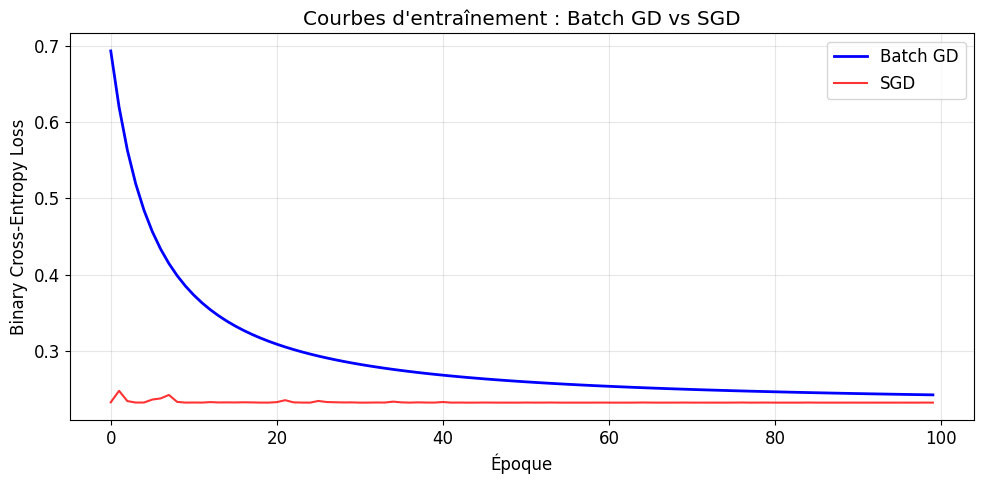

Observation : La courbe SGD peut être plus bruitée que Batch GD,
mais converge souvent plus vite en termes de temps réel (calculs par époque).


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(model_bgd.loss_history, 'b-', linewidth=2, label='Batch GD')
ax.plot(model_sgd.loss_history, 'r-', linewidth=1.5, alpha=0.8, label='SGD')
ax.set_xlabel('Époque')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Courbes d\'entraînement : Batch GD vs SGD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation : La courbe SGD peut être plus bruitée que Batch GD,")
print("mais converge souvent plus vite en termes de temps réel (calculs par époque).")

### Frontière de décision

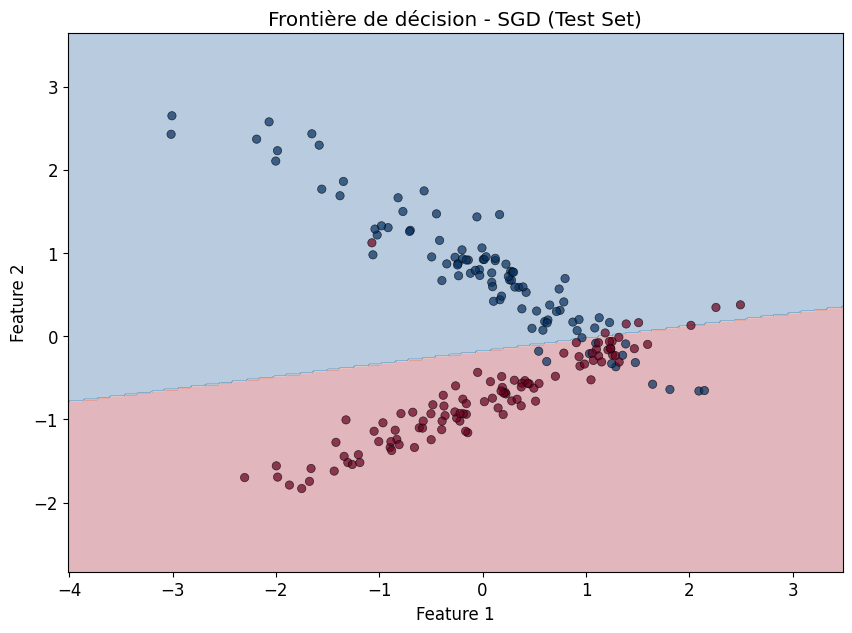

In [16]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    plt.show()

plot_decision_boundary(model_sgd, X_test, y_test, 'Frontière de décision - SGD (Test Set)')

## 7. Métriques d'Évaluation

In [17]:
def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

In [18]:
# Prédictions
y_pred_sgd = model_sgd.predict(X_test)
y_pred_bgd = model_bgd.predict(X_test)

# Métriques SGD
tp_s, tn_s, fp_s, fn_s = confusion_matrix_manual(y_test, y_pred_sgd)
# Métriques BGD
tp_b, tn_b, fp_b, fn_b = confusion_matrix_manual(y_test, y_pred_bgd)

print("=" * 55)
print("COMPARAISON DES MÉTRIQUES : SGD vs Batch GD")
print("=" * 55)
print(f"{'Métrique':<15} {'SGD':>10} {'Batch GD':>12}")
print("-" * 40)
print(f"{'Accuracy':<15} {accuracy(y_test, y_pred_sgd):>10.4f} {accuracy(y_test, y_pred_bgd):>12.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_sgd):>10.4f} {precision_score(y_test, y_pred_bgd):>12.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_sgd):>10.4f} {recall_score(y_test, y_pred_bgd):>12.4f}")
print(f"{'F1-Score':<15} {f1_score(y_test, y_pred_sgd):>10.4f} {f1_score(y_test, y_pred_bgd):>12.4f}")

COMPARAISON DES MÉTRIQUES : SGD vs Batch GD
Métrique               SGD     Batch GD
----------------------------------------
Accuracy            0.9000       0.8950
Precision           0.9222       0.9213
Recall              0.8646       0.8542
F1-Score            0.8925       0.8865


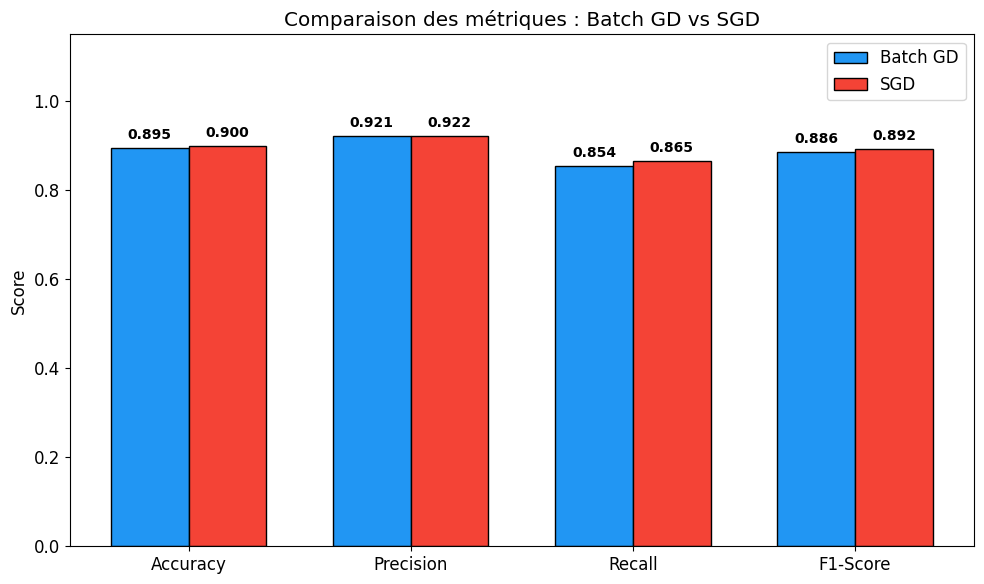

In [19]:
# Visualisation comparative des métriques
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
sgd_scores = [
    accuracy(y_test, y_pred_sgd),
    precision_score(y_test, y_pred_sgd),
    recall_score(y_test, y_pred_sgd),
    f1_score(y_test, y_pred_sgd)
]
bgd_scores = [
    accuracy(y_test, y_pred_bgd),
    precision_score(y_test, y_pred_bgd),
    recall_score(y_test, y_pred_bgd),
    f1_score(y_test, y_pred_bgd)
]

x_pos = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x_pos - width/2, bgd_scores, width, label='Batch GD', color='#2196F3', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, sgd_scores, width, label='SGD', color='#F44336', edgecolor='black')

ax.set_ylim(0, 1.15)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names)
ax.set_ylabel('Score')
ax.set_title('Comparaison des métriques : Batch GD vs SGD')
ax.legend()

# Valeurs sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

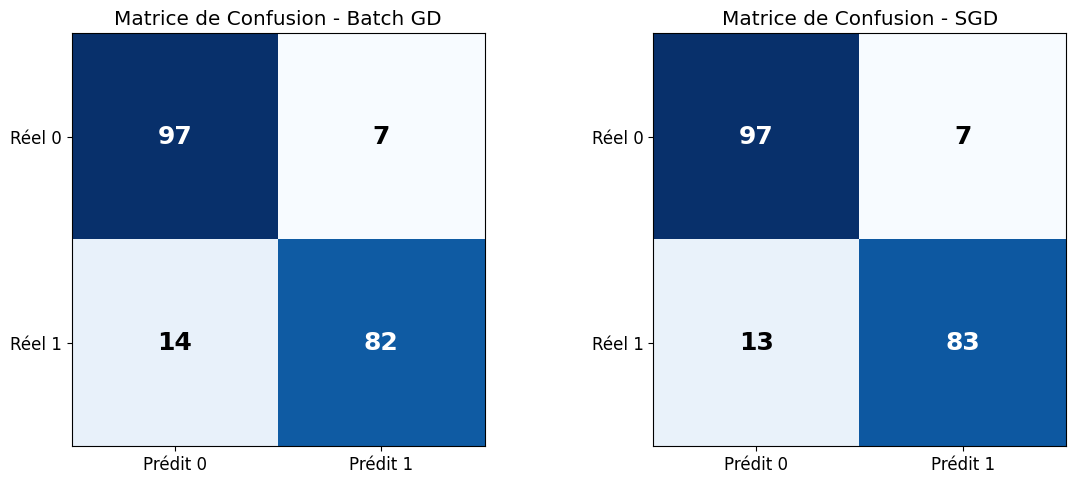

In [20]:
# Matrice de confusion SGD
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tp, tn, fp, fn, title in [
    (axes[0], tp_b, tn_b, fp_b, fn_b, 'Batch GD'),
    (axes[1], tp_s, tn_s, fp_s, fn_s, 'SGD')
]:
    cm = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Prédit 0', 'Prédit 1'])
    ax.set_yticklabels(['Réel 0', 'Réel 1'])
    ax.set_title(f'Matrice de Confusion - {title}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 8. Conclusion

### Ce qu'on a appris :
1. Le **SGD** utilise **un seul exemple** à chaque itération, ce qui le rend très rapide
2. La convergence est **bruitée** : le chemin oscille autour du minimum
3. Un **learning rate décroissant** aide le SGD à se stabiliser
4. Le bruit du SGD peut être bénéfique pour **échapper aux minima locaux**
5. En termes de qualité de classification, SGD et Batch GD donnent des résultats **similaires**

### Quand utiliser le SGD ?
- Grands datasets (le Batch GD serait trop lent)
- Apprentissage en ligne (online learning)
- Quand on veut une convergence rapide en termes de **temps réel**

### Prochain TP : Mini-batch Gradient Descent
Le **meilleur des deux mondes** : un compromis entre Batch GD et SGD.